In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print(np.random.seed(42)) #  By setting the seed to 42, you ensure that the algorithm always produces the exact same sequence of numbers every time the code is run

n = 300

x = np.random.randn(n)
y = np.random.randn(n)
z = 0.6*x + 0.2*y + np.random.randn(n)

None


In [ ]:
datos_3d = np.column_stack((x,y,z)) # une los tres datas frames independientes x, y and z
print(datos_3d.shape)

(300, 3)


In [ ]:
pca = PCA(n_components=2)
datos_2d = pca.fit_transform(datos_3d)
varianza_explicada = pca.explained_variance_ratio_
varianza_total = varianza_explicada.sum()

print(f"Dimensiones originales: {datos_3d.shape[1]}")
print(f"Dimensiones ajustadas al modelo de PCA: {datos_2d.shape[1]}")
print(f"Varianza por componente: {np.round(varianza_explicada, 2)}") # Porcentaje de informacion conservada despues del modelo PCA
print(f"Varianza total conservada por dos componentes: {varianza_total:.2f}")


Dimensiones originales: 3
Dimensiones ajustadas al modelo de PCA: 2
Varianza por componente: [0.53 0.3 ]
Varianza total conservada por dos componentes: 0.83


In [ ]:
eigenvalores = pca.explained_variance_
print(f"Eigenvalues (varianza explicada): {np.round(eigenvalores, 2)}")

eigenvectores = pca.components_
print(f"Eigenvectors (componentes principales): {np.round(eigenvectores, 2)}")

Eigenvalues (varianza explicada): [1.71 0.95]
Eigenvectors (componentes principales): [[ 0.58  0.11  0.81]
 [-0.29  0.95  0.08]]


/tmp/ipykernel_4099/3685428676.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(datos_3d[:, 0], datos_3d[:,1], datos_3d[:,2], cmap='viridis', alpha = 0.7)
/tmp/ipykernel_4099/3685428676.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(datos_2d[:,0], datos_2d[:,1],cmap ="vridis", alpha=0.7)


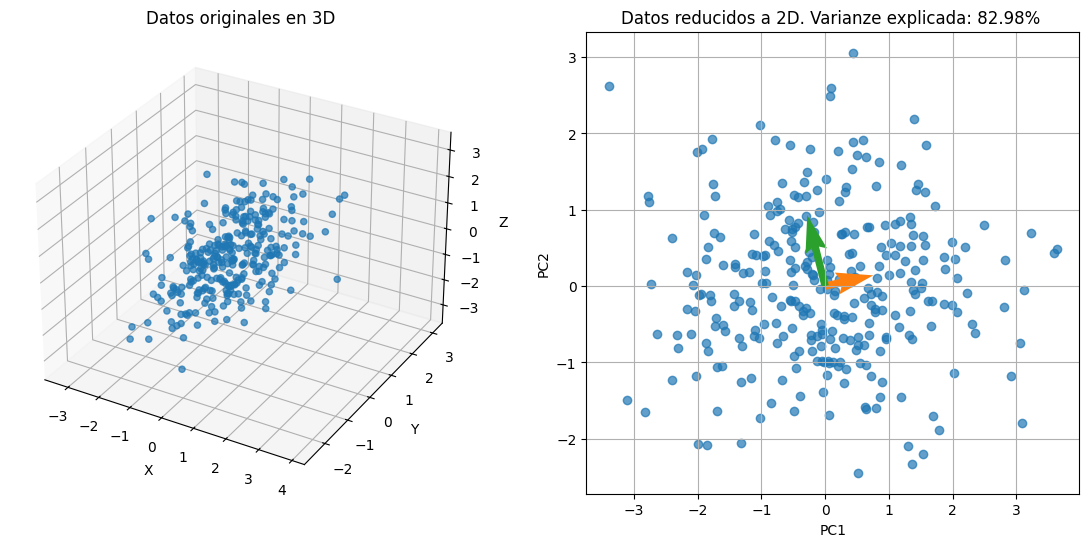

In [ ]:
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection = "3d")
ax1.scatter(datos_3d[:, 0], datos_3d[:,1], datos_3d[:,2], cmap='viridis', alpha = 0.7)
ax1.set_title("Datos originales en 3D")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

longitud1 = np.sqrt(eigenvalores[0])
longitud2 = np.sqrt(eigenvalores[1])

ax2 = fig.add_subplot(122)
ax2.scatter(datos_2d[:,0], datos_2d[:,1],cmap ="vridis", alpha=0.7)
ax2.quiver(0,0,eigenvectores[0][0]*longitud1, eigenvectores[0][1]*longitud1, angles = "xy", scale_units="xy", scale = 1, color =f"C1", width=0.015)
ax2.quiver(0,0,eigenvectores[1][0]*longitud2, eigenvectores[1][1]*longitud2, angles = "xy", scale_units="xy", scale = 1, color =f"C2", width=0.015)
ax2.set_title(f"Datos reducidos a 2D. Varianze explicada: {varianza_total:.2%} ")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.grid(True)
plt.show()
